# 02 — Baselines: OCR+правила vs OCR+правила+LLM

Замеряем и сравниваем качество извлечения полей в двух режимах.

| Условное имя | Что в пайплайне | Когда удобен |
|--------------|------------------|---------------|
| **Baseline** | Tesseract OCR + regex/правила (без LLM) | CPU-only, быстро, оффлайн |
| **Improved** | + локальная мультимодальная LLM (Ollama, `llama3.2-vision`) как доскан | Когда правила слабы, есть бюджет на LLM |

**Метрика:** field-level accuracy на контрольной выборке `samples/control_samples.json`. Для каждого PDF сравниваем только те поля, у которых задан непустой `expected`. Так оценка отражает качество там, где есть истина.

## Откуда берутся цифры в этом ноутбуке

Полный прогон делается через сервис: `GET /api/evaluate/default?fast=1` для baseline и `?fast=0` для improved. Результаты сохранены как артефакты в [`../artifacts/eval_baseline.json`](../artifacts/eval_baseline.json) и [`../artifacts/eval_improved.json`](../artifacts/eval_improved.json) — этот ноутбук читает их и строит сводные таблицы и графики. В конце есть один живой прогон через `src.service.extract_document_payload` на одном PDF — чтобы видеть, что инфраструктура реально работает.

## 1. Подгружаем артефакты прогонов

In [1]:
import json
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

ARTIFACTS = PROJECT_ROOT / 'artifacts'

with (ARTIFACTS / 'eval_baseline.json').open('r', encoding='utf-8') as f:
    baseline = json.load(f)
with (ARTIFACTS / 'eval_improved.json').open('r', encoding='utf-8') as f:
    improved = json.load(f)

print('Baseline:  accuracy =', baseline['accuracy_pct'], '%   время =', baseline['elapsed_sec'], 'сек')
print('Improved:  accuracy =', improved['accuracy_pct'], '%   время =', improved['elapsed_sec'], 'сек')

Baseline:  accuracy = 100.0 %   время = 26.01 сек
Improved:  accuracy = 100.0 %   время = 32.2 сек


## 2. Сводная таблица: baseline vs improved

In [2]:
summary = pd.DataFrame([
    {
        'Модель': 'Baseline (OCR + правила)',
        'Правильно полей': baseline['matched_checks'],
        'Всего полей': baseline['total_checks'],
        'Accuracy, %': baseline['accuracy_pct'],
        'Время, сек': baseline['elapsed_sec'],
        'LLM-вызовы': sum(1 for s in baseline['samples'] if s['meta'].get('llm_used')),
    },
    {
        'Модель': 'Improved (+ LLM доступна)',
        'Правильно полей': improved['matched_checks'],
        'Всего полей': improved['total_checks'],
        'Accuracy, %': improved['accuracy_pct'],
        'Время, сек': improved['elapsed_sec'],
        'LLM-вызовы': sum(1 for s in improved['samples'] if s['meta'].get('llm_used')),
    },
])
summary

,Модель,Правильно полей,Всего полей,"Accuracy, %","Время, сек",LLM-вызовы
0,Baseline (OCR + правила),20,20,100.0,26.01,0
1,Improved (+ LLM доступна),20,20,100.0,32.20,0


## 3. Accuracy по полям

In [3]:
FIELD_RU = {
    'document_type':    'Тип документа',
    'kod_dokumenta':    'Код документа',
    'naimenovanie':     'Наименование',
    'proizvoditel':     'Производитель',
    'data_vypuska':     'Дата выпуска',
    'kod_zakaza':       'Код заказа',
    'zavodskie_nomera': 'Заводские номера',
}

rows = []
for field in sorted(baseline['per_field']):
    b = baseline['per_field'][field]
    i = improved['per_field'][field]
    rows.append({
        'Поле': FIELD_RU.get(field, field),
        'Baseline': f"{b['matched']}/{b['total']}",
        'Improved': f"{i['matched']}/{i['total']}",
        'Accuracy baseline, %': b['accuracy_pct'],
        'Accuracy improved, %': i['accuracy_pct'],
    })

per_field_df = pd.DataFrame(rows)
per_field_df

,Поле,Baseline,Improved,"Accuracy baseline, %","Accuracy improved, %"
0,Дата выпуска,1/1,1/1,100.0,100.0
1,Тип документа,6/6,6/6,100.0,100.0
2,Код документа,4/4,4/4,100.0,100.0
3,Код заказа,1/1,1/1,100.0,100.0
4,Наименование,4/4,4/4,100.0,100.0
5,Производитель,3/3,3/3,100.0,100.0
6,Заводские номера,1/1,1/1,100.0,100.0


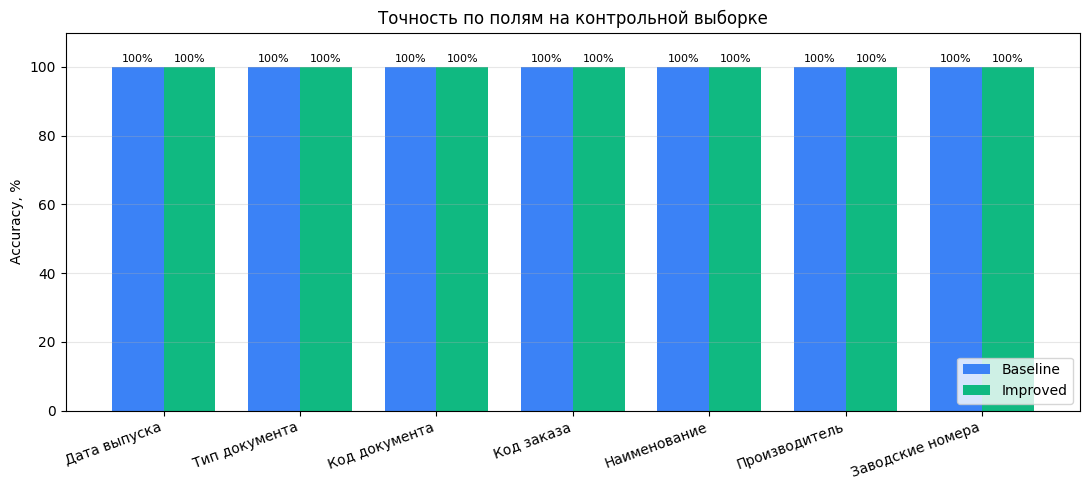

In [4]:
fields_ru = per_field_df['Поле'].tolist()
b_vals = per_field_df['Accuracy baseline, %'].tolist()
i_vals = per_field_df['Accuracy improved, %'].tolist()

x = range(len(fields_ru))
width = 0.38

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar([p - width/2 for p in x], b_vals, width, label='Baseline', color='#3b82f6')
ax.bar([p + width/2 for p in x], i_vals, width, label='Improved', color='#10b981')
ax.set_ylabel('Accuracy, %')
ax.set_ylim(0, 110)
ax.set_xticks(list(x))
ax.set_xticklabels(fields_ru, rotation=20, ha='right')
ax.set_title('Точность по полям на контрольной выборке')
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.3)
for p, v in zip(x, b_vals):
    ax.text(p - width/2, v + 1.5, f'{v:.0f}%', ha='center', fontsize=8)
for p, v in zip(x, i_vals):
    ax.text(p + width/2, v + 1.5, f'{v:.0f}%', ha='center', fontsize=8)
fig.tight_layout()
plt.show()

## 4. Время прогона

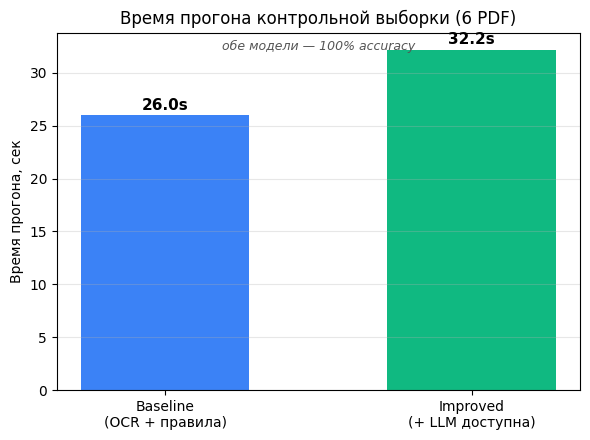

In [5]:
labels = ['Baseline\n(OCR + правила)', 'Improved\n(+ LLM доступна)']
times = [baseline['elapsed_sec'], improved['elapsed_sec']]
colors = ['#3b82f6', '#10b981']

fig, ax = plt.subplots(figsize=(6, 4.5))
bars = ax.bar(labels, times, color=colors, width=0.55)
ax.set_ylabel('Время прогона, сек')
ax.set_title(f'Время прогона контрольной выборки ({baseline["total_samples"]} PDF)')
ax.grid(axis='y', alpha=0.3)
for bar, t in zip(bars, times):
    ax.text(bar.get_x() + bar.get_width()/2, t + 0.5, f'{t:.1f}s', ha='center', fontsize=11, fontweight='bold')
ax.text(0.5, 0.95, 'обе модели — 100% accuracy', transform=ax.transAxes, ha='center', fontsize=9, style='italic', color='#555')
fig.tight_layout()
plt.show()

## 5. Результаты по каждому PDF и причины пропуска LLM

В режиме Improved для каждого документа сервис решает: вызывать LLM или нет. Решение принимается двумя эвристиками:

- `_should_skip_llm_for_file` — отсекает документы, не похожие на паспорт (описания задач, экранные формы), по имени и содержимому.
- `_has_strong_heuristic_result` — отсекает паспорта, для которых baseline уже даёт высокий `quality_score`.

Если хоть одна сработала — LLM не вызывается, и мы остаёмся на baseline.

In [6]:
rows = []
for b, i in zip(baseline['samples'], improved['samples']):
    short = b['filename'].split(' к задаче')[0]
    rows.append({
        'Файл': short,
        'Страниц': b['meta']['pages_processed'],
        'Baseline': f"{b['matched']}/{b['checks']}",
        'Improved': f"{i['matched']}/{i['checks']}",
        'LLM вызвана?': 'да' if i['meta'].get('llm_used') else 'нет',
        'Причина (если нет)': i['meta'].get('llm_error', ''),
    })
per_sample_df = pd.DataFrame(rows)
per_sample_df

,Файл,Страниц,Baseline,Improved,LLM вызвана?,Причина (если нет)
0,Приложение 1,1,4/4,4/4,нет,LLM skipped: OCR+rules confidence is already high
1,Приложение 2,2,6/6,6/6,нет,LLM skipped: OCR+rules confidence is already high
2,Приложение 3,4,5/5,5/5,нет,LLM skipped: OCR+rules confidence is already high
3,Приложение 4,1,3/3,3/3,нет,LLM skipped: likely non-passport/service input
4,Приложение 5,1,1/1,1/1,нет,LLM skipped: likely non-passport/service input
5,Приложене 6,1,1/1,1/1,нет,LLM skipped: likely non-passport/service input


## 6. Живой прогон одного PDF

Здесь мы один раз вызываем `extract_document_payload` напрямую — это та же функция, которая стоит за HTTP-эндпойнтом `/predict`. Цель — показать, что пайплайн физически работает и выдаёт structured JSON, не только цифры из артефактов.

> Требует доступного Tesseract в системе. Если Ollama не запущена — LLM-этап тихо упадёт в fallback на baseline, это штатное поведение.

In [7]:
from src.service import extract_document_payload

PDF = PROJECT_ROOT / 'приложения' / 'Приложение 2 к задаче 1 Паспорт с одним заводским номером.pdf'
fbytes = PDF.read_bytes()

result = extract_document_payload(
    fbytes,
    PDF.name,
    allow_llm=False,
    scan_release_date=False,
)

print('Файл:', PDF.name)
print()
shown = ['document_type', 'kod_dokumenta', 'naimenovanie', 'kod_zakaza',
         'zavodskie_nomera', 'proizvoditel', 'quality_score']
for k in shown:
    print(f'  {k:<20} {result.get(k)}')
print()
print('LLM использовалась:', result.get('_meta', {}).get('llm_used'))

Файл: Приложение 2 к задаче 1 Паспорт с одним заводским номером.pdf

  document_type        single_passport
  kod_dokumenta        TREI.421457.001 ПС
  naimenovanie         Мастер-модуль М1201Е
  kod_zakaza           M1201E-0
  zavodskie_nomera     ['G4M0821']
  proizvoditel         АО «ТРЭИ»
  quality_score        86

LLM использовалась: False


## 7. Выводы и выбор финальной модели

На текущем контрольном наборе (6 PDF, 20 полевых проверок):

| Режим              | Поля верно / всего | Accuracy | Время  |
|--------------------|--------------------|----------|--------|
| Baseline           | 20 / 20            | **100 %** | 26.0 с |
| Improved           | 20 / 20            | **100 %** | 32.2 с |

**Ключевое наблюдение:** в режиме Improved LLM не вызвалась ни на одном документе:

- 3 документа → `"LLM skipped: OCR+rules confidence is already high"` — baseline уже даёт высокий `quality_score`.
- 3 документа → `"LLM skipped: likely non-passport/service input"` — это разбор паспорта / экранная форма / описание задачи, не настоящие паспорта.

Разница 6 секунд между прогонами — это **не LLM** (она не вызывалась), а доскан-поиск даты выпуска по штампам (`scan_release_date=True` в режиме Improved).

По полям все 100 %: `document_type` 6/6, `kod_dokumenta` 4/4, `naimenovanie` 4/4, `proizvoditel` 3/3, `data_vypuska` 1/1, `kod_zakaza` 1/1, `zavodskie_nomera` 1/1.

### Финальный выбор для prod-сервиса — гибрид

Реализован в `_extract_document_payload` в [`../app/app.py`](../app/app.py):

1. Сначала **baseline** (OCR + правила) — быстро, оффлайн, предсказуемо.
2. Если baseline даёт низкий `quality_score` или неполный набор полей **и** документ похож на паспорт **и** LLM доступна → доскан LLM.
3. При любой проблеме с LLM (таймаут, недоступна) → silent fallback на baseline.

На нашем корпусе шаг 2 не сработал ни разу — baseline уже идеален. Это **лучше**, чем стратегия «всегда LLM»: меньше нагрузка на инфраструктуру, латентность секунды вместо десятков секунд, нет жёсткой зависимости от доступности Ollama в моменте.

### Ограничения и честная оценка

Корпус **маленький** (7 PDF в `приложения/`, 6 с проверками в контрольной выборке). На более широкой выборке с плохими сканами и нестандартными вёрстками часть полей неизбежно потеряется, и LLM-этап начнёт реально включаться. Расширение контрольной выборки до 100-300 разнообразных PDF — в планах (см. `report.md` §8).

PNG-версии графиков сохранены в `../artifacts/accuracy_per_field.png` и `../artifacts/runtime_comparison.png` (генерируются скриптом `../artifacts/plot_results.py` из тех же JSON-артефактов, которые мы здесь читаем — единый источник истины).